## Load dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("students.csv")

print("Dataset loaded successfully.\n")

Dataset loaded successfully.



## Task 1 — Data Exploration with Pandas 
## Show first 5 rows

In [3]:
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


## Show shape of dataset

In [4]:
print("\nShape of dataset:")
print(df.shape)


Shape of dataset:
(15, 9)


## Show data types

In [5]:
print("\nData types of each column:")
print(df.dtypes)


Data types of each column:
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


## Show summary statistics

In [6]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               

## Count how many students passed and failed

In [7]:
print("Number of students who passed:", df["passed"].value_counts()[1])
print("Number of students who failed:", df["passed"].value_counts()[0])

Number of students who passed: 9
Number of students who failed: 6


## Store subject names in a list

In [8]:
subject_cols = ["math", "science", "english", "history", "pe"]


## Average marks of students who passed

In [9]:
passing_students = df[df["passed"] == 1]
passing_avg = passing_students[subject_cols].mean()

print("\nAverage subject scores for passing students:")
print(passing_avg)


Average subject scores for passing students:
math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64


## Average marks of students who failed

In [10]:
failing_students = df[df["passed"] == 0]
failing_avg = failing_students[subject_cols].mean()

print("\nAverage subject scores for failing students:")
print(failing_avg)



Average subject scores for failing students:
math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64


## new column for overall average

In [11]:
df["average_score"] = df[subject_cols].mean(axis=1)

## student with the highest average

In [12]:
top_student = df.loc[df["average_score"].idxmax()]

print("\nStudent with the highest overall average:")
print(top_student[["name", "average_score"]])


Student with the highest overall average:
name             Diana
average_score     94.0
Name: 3, dtype: object


## Observation

From the data, I can see that students who passed have higher average marks in all subjects compared to students who failed. The student with the highest overall average scored well in all five subjects.

In [15]:
%pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.3 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 29.7 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 19.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 31.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 53.9 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 33.9 MB/s  0:00:00

   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ---------------------------------------- 0/7 [pyparsing]
   ------------------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Task 2 — Data Visualization with Matplotlib

## Import matplotlib

In [17]:
import matplotlib.pyplot as plt
print("matplotlib imported successfully")

Matplotlib is building the font cache; this may take a moment.


matplotlib imported successfully


In [18]:
import matplotlib.pyplot as plt

## Create the avg_score column

In [19]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

print(df[['name', 'avg_score']].head())

      name  avg_score
0    Alice       86.2
1      Bob       51.0
2  Charlie       76.2
3    Diana       94.0
4      Eve       46.0


## Plot 1 — Bar Chart
## Average score per subject across all students

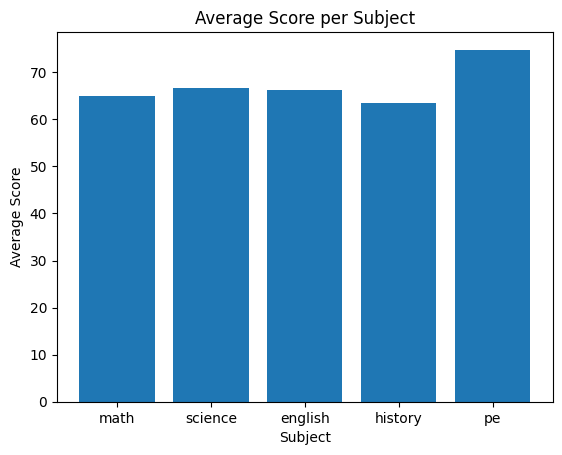

In [25]:
subject_avg = df[subject_cols].mean()

plt.bar(subject_avg.index, subject_avg.values)
plt.title("Average Score per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

## Plot 2 — Histogram
## Distribution of math scores

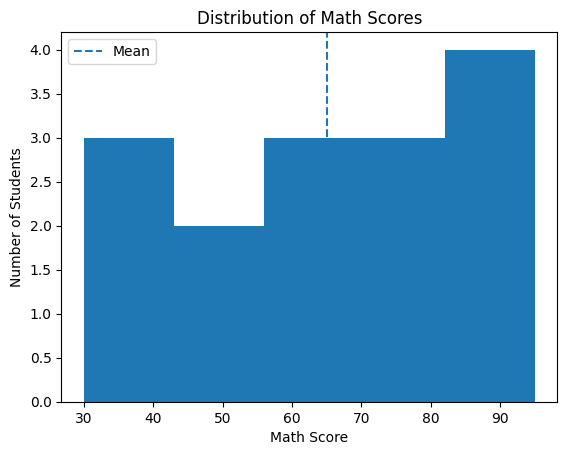

In [30]:
math_mean = df['math'].mean()

plt.hist(df['math'], bins=5)
plt.axvline(math_mean, linestyle='--', label='Mean')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

## Plot 3 — Scatter Plot
## Study hours per day vs average score

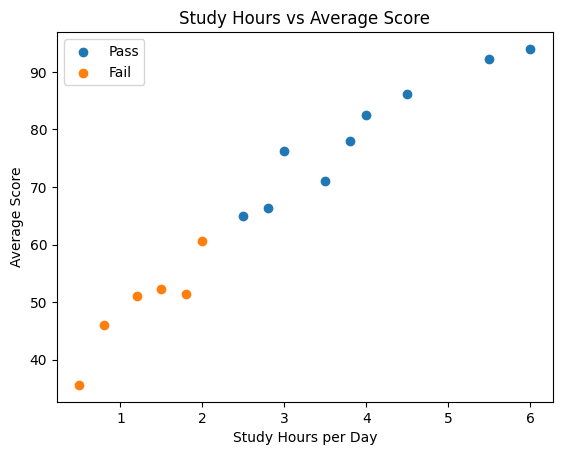

In [34]:
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

## Plot 4 — Box Plot
## Attendance percentage for passing vs failing students

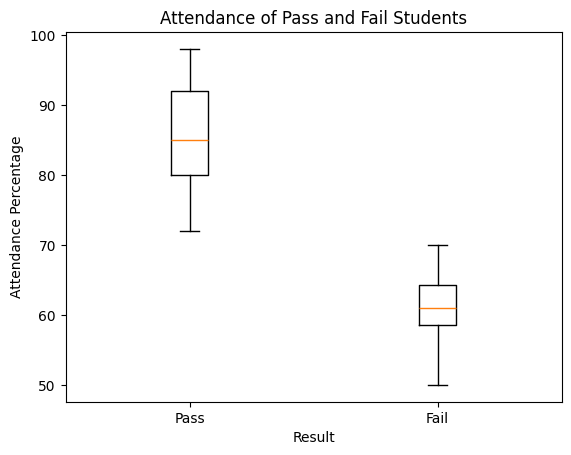

In [43]:
pass_attendance = df[df['passed'] == 1]['attendance_pct']
fail_attendance = df[df['passed'] == 0]['attendance_pct']

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])
plt.title("Attendance of Pass and Fail Students")
plt.xlabel("Result")
plt.ylabel("Attendance Percentage")
plt.savefig("plot4_boxplot.png")
plt.show()

## Plot 5 — Line Plot
## Math and science score for every student

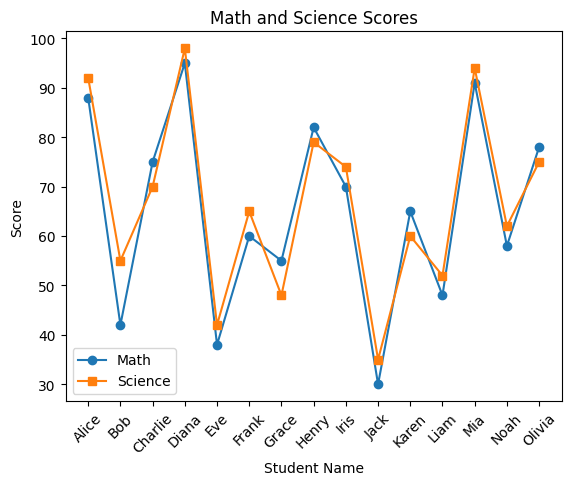

In [44]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='s', label='Science')
plt.title("Math and Science Scores")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()

## Observation


The plots show that students who study more and have better attendance tend to perform better. 
The graphs also help compare subject scores and understand the distribution of marks.